In [1]:
import pandas as pd
df = pd.read_csv("ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [3]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [4]:
df["user_id"].duplicated().sum()

np.int64(3894)

In [5]:
df["user_id"].nunique()

290584

In [6]:
df["user_id"].value_counts().value_counts()


count
1    286690
2      3894
Name: count, dtype: int64

In [7]:
df["user_id"].value_counts().head(10)


user_id
635984    2
905609    2
895459    2
770459    2
692897    2
742690    2
657619    2
866294    2
676899    2
848305    2
Name: count, dtype: int64

In [8]:
duplicate_users = df[df["user_id"].duplicated(keep=False)]

duplicate_users.sort_values("user_id").head(20)


,user_id,timestamp,group,landing_page,converted
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
11792,630137,2017-01-22 14:59:22.051308,control,new_page,0
183371,630137,2017-01-20 02:08:49.893878,control,old_page,0
255753,630320,2017-01-12 05:27:37.181803,treatment,old_page,0
207211,630320,2017-01-07 18:02:43.626318,control,old_page,0
110634,630471,2017-01-23 01:42:51.501851,control,old_page,0
96929,630471,2017-01-07 02:14:17.405726,control,new_page,0


In [9]:
duplicate_users.groupby("user_id")["group"].nunique().value_counts()

group
1    1999
2    1895
Name: count, dtype: int64

In [10]:
duplicate_users.groupby("user_id")["landing_page"].nunique().value_counts()


landing_page
2    1998
1    1896
Name: count, dtype: int64

In [11]:
duplicate_users.groupby("user_id")["landing_page"].nunique().value_counts()

landing_page
2    1998
1    1896
Name: count, dtype: int64

In [12]:
pd.crosstab(df["group"], df["landing_page"])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [13]:
df_clean = df[
    ((df["group"] == "control") & (df["landing_page"] == "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
].copy()

df_clean.shape

(290585, 5)

In [14]:
pd.crosstab(df_clean["group"], df_clean["landing_page"])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [15]:
df_clean.groupby("group")["converted"].agg(
    users="count",
    conversions="sum"
)

,users,conversions
group,,
control,145274,17489
treatment,145311,17264


In [16]:
conversion_rates = (
    df_clean.groupby("group")["converted"]
    .mean()
    .mul(100)
)

conversion_rates

group
control      12.038630
treatment    11.880725
Name: converted, dtype: float64

In [17]:
from statsmodels.stats.proportion import proportions_ztest

In [18]:
conversions = df_clean.groupby("group")["converted"].sum()
users = df_clean.groupby("group")["converted"].count()

count = [
    conversions["control"],
    conversions["treatment"]
]

nobs = [
    users["control"],
    users["treatment"]
]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.3116075339133115
P-value: 0.18965258971881804


In [19]:
from statsmodels.stats.proportion import confint_proportions_2indep

control_conv = conversions["control"]
treatment_conv = conversions["treatment"]

control_users = users["control"]
treatment_users = users["treatment"]

ci_low, ci_high = confint_proportions_2indep(
    treatment_conv,
    treatment_users,
    control_conv,
    control_users,
    method="wald"
)

print("95% CI:", ci_low, "to", ci_high)

95% CI: -0.00393867032963623 to 0.0007805571342619391


In [20]:
df_clean["timestamp"] = pd.to_datetime(df_clean["timestamp"])

df_clean["date"] = df_clean["timestamp"].dt.date

df_clean.head()

,user_id,timestamp,group,landing_page,converted,date
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21


In [21]:
daily_conversion = (
    df_clean.groupby(["date", "group"])["converted"]
    .mean()
    .mul(100)
    .reset_index()
)

daily_conversion.head(10)

,date,group,converted
0,2017-01-02,control,12.556838
1,2017-01-02,treatment,11.987382
2,2017-01-03,control,11.380880
3,2017-01-03,treatment,11.378060
4,2017-01-04,control,12.192156
5,2017-01-04,treatment,11.664883
6,2017-01-05,control,12.323012
7,2017-01-05,treatment,11.498847
8,2017-01-06,control,11.534968
9,2017-01-06,treatment,12.346228


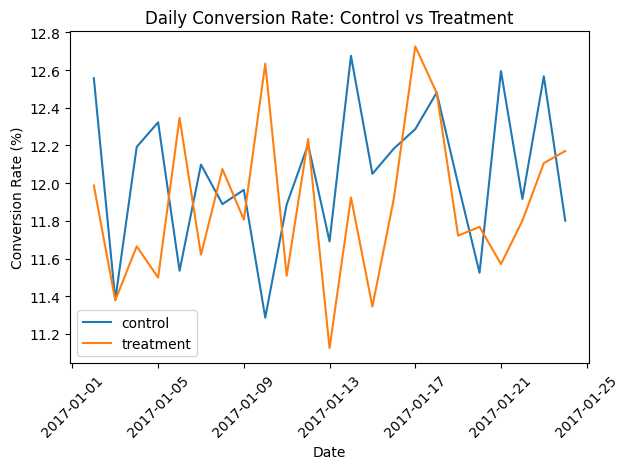

In [22]:
import matplotlib.pyplot as plt

for group in ["control", "treatment"]:
    data = daily_conversion[daily_conversion["group"] == group]
    
    plt.plot(
        data["date"],
        data["converted"],
        label=group
    )

plt.title("Daily Conversion Rate: Control vs Treatment")
plt.xlabel("Date")
plt.ylabel("Conversion Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Check duplicate users after group/page cleaning

df_clean["user_id"].duplicated().sum()

np.int64(1)

In [24]:
df_clean[df_clean["user_id"].duplicated(keep=False)]

,user_id,timestamp,group,landing_page,converted,date
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0,2017-01-09
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0,2017-01-14


In [25]:
df_final = df_clean.drop_duplicates(
    subset="user_id",
    keep="first"
).copy()

print("Rows before:", len(df_clean))
print("Rows after:", len(df_final))
print("Duplicate users remaining:", df_final["user_id"].duplicated().sum())

Rows before: 290585
Rows after: 290584
Duplicate users remaining: 0


In [26]:
# Final conversion metrics after user-level cleaning

final_results = (
    df_final.groupby("group")["converted"]
    .agg(
        users="count",
        conversions="sum"
    )
)

final_results["conversion_rate"] = (
    final_results["conversions"] / final_results["users"] * 100
)

final_results

,users,conversions,conversion_rate
group,,,
control,145274,17489,12.038630
treatment,145310,17264,11.880807


In [27]:
from statsmodels.stats.proportion import proportions_ztest

# Final conversion counts
count = [
    final_results.loc["control", "conversions"],
    final_results.loc["treatment", "conversions"]
]

# Final user counts
nobs = [
    final_results.loc["control", "users"],
    final_results.loc["treatment", "users"]
]

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 1.3109241984234394
P-value: 0.18988337448195103


In [28]:
from statsmodels.stats.proportion import confint_proportions_2indep

control_conv = final_results.loc["control", "conversions"]
treatment_conv = final_results.loc["treatment", "conversions"]

control_users = final_results.loc["control", "users"]
treatment_users = final_results.loc["treatment", "users"]

ci_low, ci_high = confint_proportions_2indep(
    treatment_conv,
    treatment_users,
    control_conv,
    control_users,
    method="wald"
)

print("95% CI:", ci_low, "to", ci_high)
print("95% CI in percentage points:",
      ci_low * 100, "to", ci_high * 100)

95% CI: -0.003937860245052737 to 0.0007813822743416238
95% CI in percentage points: -0.3937860245052737 to 0.07813822743416238


In [30]:
df_final.to_csv("ab_testing_final.csv", index=False)

print("Final dataset saved successfully.")
print("Rows:", len(df_final))

Final dataset saved successfully.
Rows: 290584
